# 1 - Inicialização

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


# 2 - Carregando os Dados

In [26]:
df = pd.read_csv('/datasets/gym_churn_us.csv')

# 3 - Analisando o DF

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   gender                             4000 non-null   int64  
 1   Near_Location                      4000 non-null   int64  
 2   Partner                            4000 non-null   int64  
 3   Promo_friends                      4000 non-null   int64  
 4   Phone                              4000 non-null   int64  
 5   Contract_period                    4000 non-null   int64  
 6   Group_visits                       4000 non-null   int64  
 7   Age                                4000 non-null   int64  
 8   Avg_additional_charges_total       4000 non-null   float64
 9   Month_to_end_contract              4000 non-null   float64
 10  Lifetime                           4000 non-null   int64  
 11  Avg_class_frequency_total          4000 non-null   float

In [28]:
df.columns = df.columns.str.lower()

In [29]:
df.head()

,gender,near_location,partner,promo_friends,phone,contract_period,group_visits,age,avg_additional_charges_total,month_to_end_contract,lifetime,avg_class_frequency_total,avg_class_frequency_current_month,churn
0,1,1,1,1,0,6,1,29,14.227470,5.0,3,0.020398,0.000000,0
1,0,1,0,0,1,12,1,31,113.202938,12.0,7,1.922936,1.910244,0
2,0,1,1,0,1,1,0,28,129.448479,1.0,2,1.859098,1.736502,0
3,0,1,1,1,1,12,1,33,62.669863,12.0,2,3.205633,3.357215,0
4,1,1,1,1,1,1,0,26,198.362265,1.0,3,1.113884,1.120078,0


In [30]:
df.describe()

,gender,near_location,partner,promo_friends,phone,contract_period,group_visits,age,avg_additional_charges_total,month_to_end_contract,lifetime,avg_class_frequency_total,avg_class_frequency_current_month,churn
count,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000
mean,0.510250,0.845250,0.486750,0.308500,0.903500,4.681250,0.412250,29.184250,146.943728,4.322750,3.724750,1.879020,1.767052,0.265250
std,0.499957,0.361711,0.499887,0.461932,0.295313,4.549706,0.492301,3.258367,96.355602,4.191297,3.749267,0.972245,1.052906,0.441521
min,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,18.000000,0.148205,1.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,27.000000,68.868830,1.000000,1.000000,1.180875,0.963003,0.000000
50%,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,29.000000,136.220159,1.000000,3.000000,1.832768,1.719574,0.000000
75%,1.000000,1.000000,1.000000,1.000000,1.000000,6.000000,1.000000,31.000000,210.949625,6.000000,5.000000,2.536078,2.510336,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,12.000000,1.000000,41.000000,552.590740,12.000000,31.000000,6.023668,6.146783,1.000000


In [31]:
# Agrupar por 'churn' a contar a quantidade
df_grouped_churn = df.groupby(by='churn')['gender'].count().reset_index()
df_grouped_churn.columns=['churn', 'amount']
df_grouped_churn.head()

,churn,amount
0,0,2939
1,1,1061


In [32]:
# Agrupar por 'churn' a mostrar a média
df_grouped_churn = df.groupby(by='churn').mean().reset_index()
df_grouped_churn.head()

,churn,gender,near_location,partner,promo_friends,phone,contract_period,group_visits,age,avg_additional_charges_total,month_to_end_contract,lifetime,avg_class_frequency_total,avg_class_frequency_current_month
0,0,0.510037,0.873086,0.534195,0.353522,0.903709,5.747193,0.464103,29.976523,158.445715,5.283089,4.711807,2.024876,2.027882
1,1,0.510839,0.768143,0.355325,0.183789,0.902922,1.728558,0.268615,26.989632,115.082899,1.662582,0.990575,1.474995,1.044546


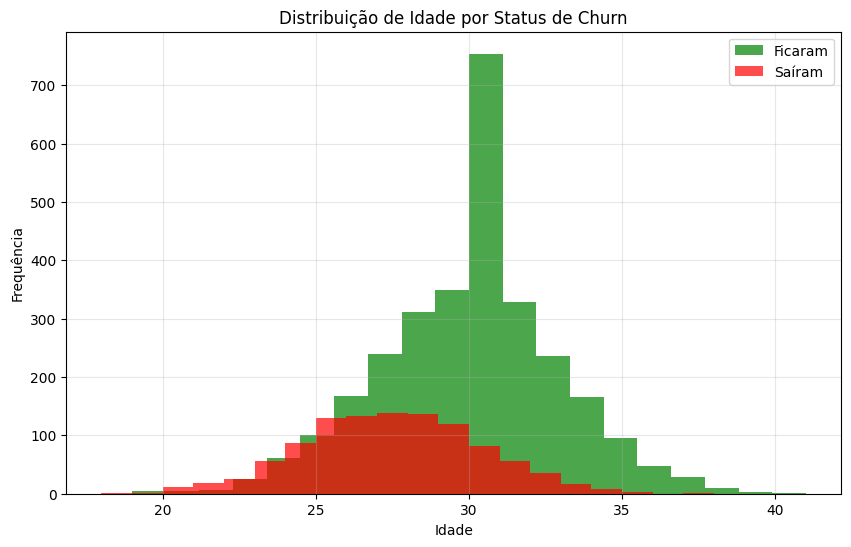

In [33]:
# Histograma para age
# criar uma figura
plt.figure(figsize=(10,6))

# Histograma para clientes que ficaram
plt.hist(df[df['churn']==0]['age'], bins=20, alpha=0.7, label='Ficaram', color='green')

# Histograma para clientes que saíram
plt.hist(df[df['churn']==1]['age'], bins=20, alpha=0.7, label='Saíram', color='red')

# Detalhes
plt.title('Distribuição de Idade por Status de Churn')
plt.xlabel('Idade')
plt.ylabel('Frequência')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

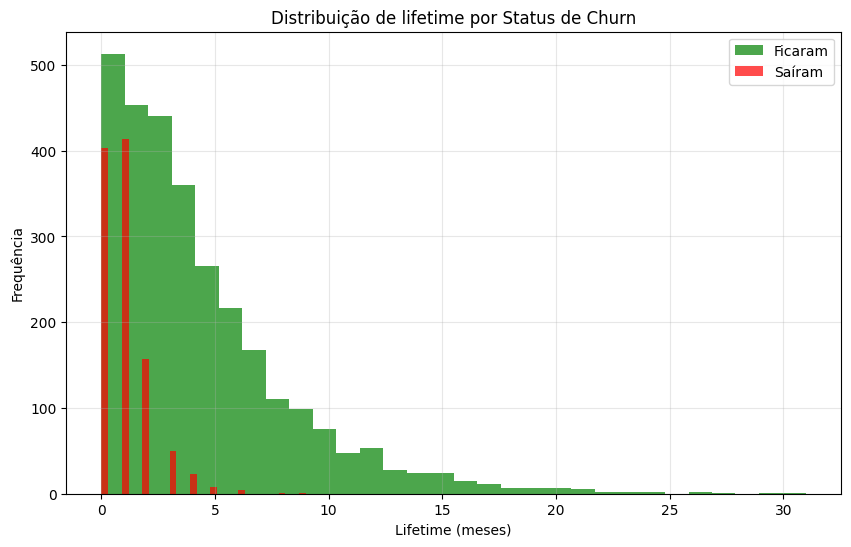

In [34]:
# Histograma para lifetime
# criar uma figura
plt.figure(figsize=(10,6))

# Histograma para clientes que ficaram
plt.hist(df[df['churn']==0]['lifetime'], bins=30, alpha=0.7, label='Ficaram', color='green')

# Histograma para clientes que saíram
plt.hist(df[df['churn']==1]['lifetime'], bins=30, alpha=0.7, label='Saíram', color='red')

# Detalhes
plt.title('Distribuição de lifetime por Status de Churn')
plt.xlabel('Lifetime (meses)')
plt.ylabel('Frequência')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

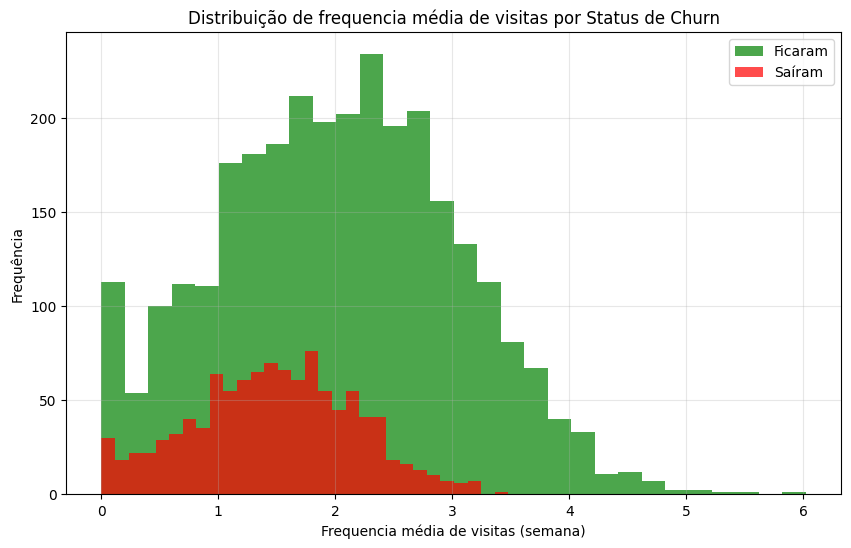

In [35]:

# Histograma para avg_class_frequency_total
# criar uma figura
plt.figure(figsize=(10,6))

# Histograma para clientes que ficaram
plt.hist(df[df['churn']==0]['avg_class_frequency_total'], bins=30, alpha=0.7, label='Ficaram', color='green')

# Histograma para clientes que saíram
plt.hist(df[df['churn']==1]['avg_class_frequency_total'], bins=30, alpha=0.7, label='Saíram', color='red')

# Detalhes
plt.title('Distribuição de frequencia média de visitas por Status de Churn')
plt.xlabel('Frequencia média de visitas (semana)')
plt.ylabel('Frequência')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


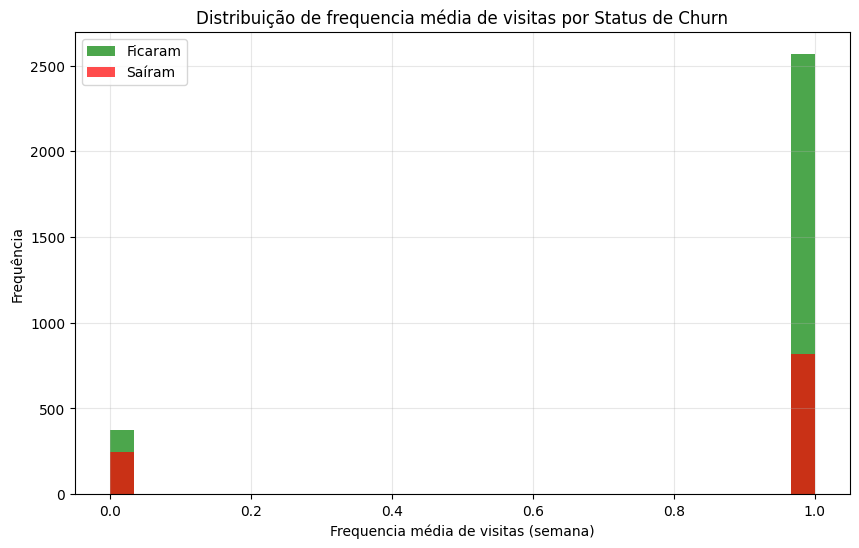

In [36]:
# Histograma para near_location
# criar uma figura
plt.figure(figsize=(10,6))

# Histograma para clientes que ficaram
plt.hist(df[df['churn']==0]['near_location'], bins=30, alpha=0.7, label='Ficaram', color='green')

# Histograma para clientes que saíram
plt.hist(df[df['churn']==1]['near_location'], bins=30, alpha=0.7, label='Saíram', color='red')

# Detalhes
plt.title('Distribuição de frequencia média de visitas por Status de Churn')
plt.xlabel('Frequencia média de visitas (semana)')
plt.ylabel('Frequência')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

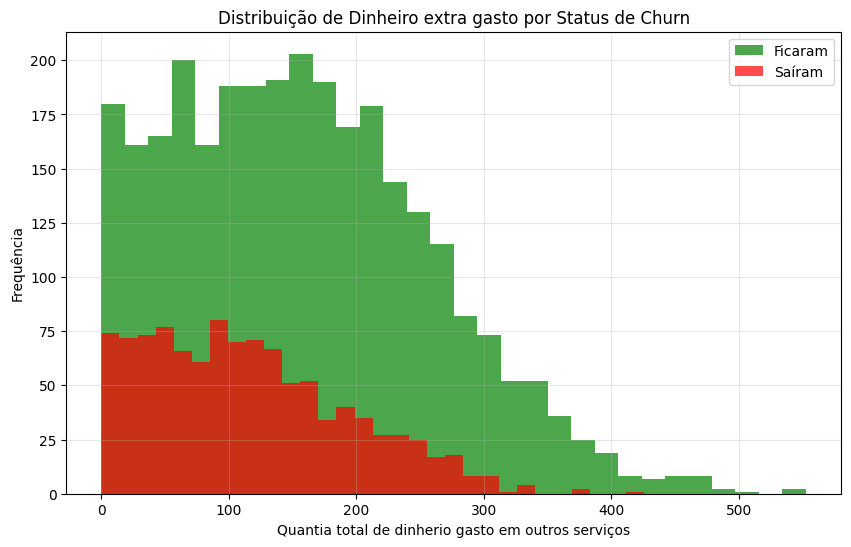

In [37]:
# Histograma para avg_additional_charges_total
# criar uma figura
plt.figure(figsize=(10,6))

# Histograma para clientes que ficaram
plt.hist(df[df['churn']==0]['avg_additional_charges_total'], bins=30, alpha=0.7, label='Ficaram', color='green')

# Histograma para clientes que saíram
plt.hist(df[df['churn']==1]['avg_additional_charges_total'], bins=30, alpha=0.7, label='Saíram', color='red')

# Detalhes
plt.title('Distribuição de Dinheiro extra gasto por Status de Churn')
plt.xlabel('Quantia total de dinherio gasto em outros serviços')
plt.ylabel('Frequência')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Observações:
* Não há valores ausentes
* Clientes que ficam churn=0, clientes que deixam churn=1
* Clientes que moram perto da academia=1, clientes que moram longe da academia=0
* Idades que mais deixam de usar: entre 25 e 30 anos
* Os clientes que deixam a academia, costumam deixar nos primeiros meses de uso
* Clientes que deixam usam a academia por 1 ou 2 semanas no mês
* Maior taxa de clientes que deixam a academia moram perto.
* A maioria dos clientes que deixaram a academia gstou pouco em outros produtos

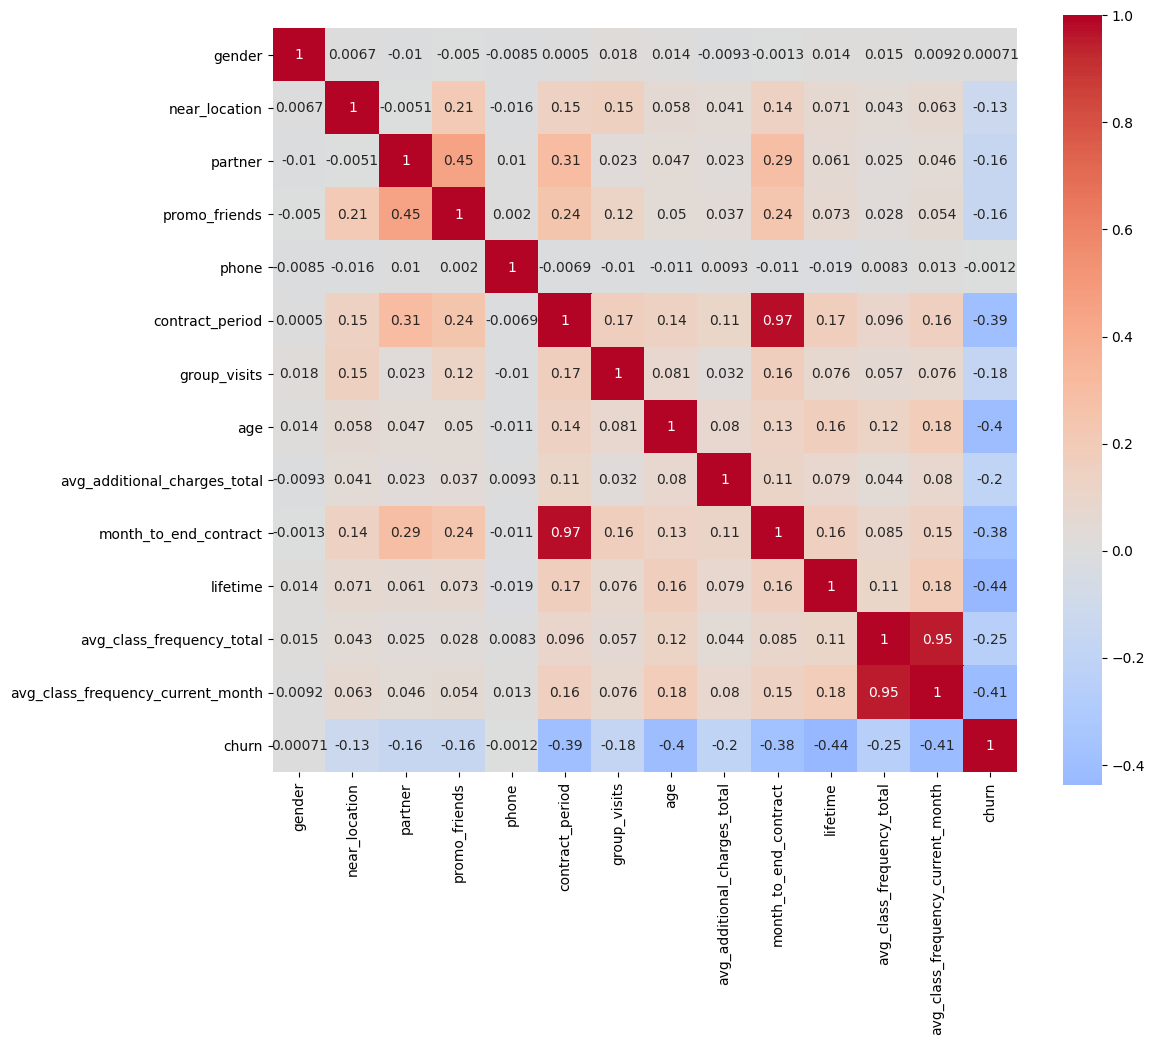

In [38]:
# Construindo e renderizando uma matriz de correlação

cm = df.corr()#criando a matriz de correlação
fig, ax = plt.subplots(figsize=(12,10))

# Mapa de calor anotado para a matriz de correlação
sns.heatmap(cm, annot=True, cmap='coolwarm', center=0, square=True)
plt.show()

# 3 - Construção de um modelo para predizer a rotatividade de clientes

In [39]:
# dividir os dados em características (a matriz X) e a variável objetivo (y)
X = df.drop(columns = ['churn'])
y = df['churn']

In [40]:
# Dividir os dados em conjuntos de treino e de teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

## 3.1 - Treinar o modelo de Regressão Lgistica

In [59]:
# Criar e treinar o modelo de Regressão Logística
lr_model = LogisticRegression(random_state=0)
lr_model.fit(X_train, y_train)

/.venv/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:763: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(random_state=0)

In [42]:
# Fazer previsões
lr_predictions = lr_model.predict(X_test)

In [43]:
# Avaliar o modelo
print('Acurácia: {:.2f}'.format(accuracy_score(y_test, lr_predictions)))
print('Precisão: {:.2f}'.format(precision_score(y_test, lr_predictions)))
print('Sensibilidade: {:.2f}'.format(recall_score(y_test, lr_predictions)))

Acurácia: 0.91
Precisão: 0.90
Sensibilidade: 0.76


## 3.2 - Treinar o modelo Randon Forest

In [44]:
# Criar e treinar o modelo Random Forest
rf_model = RandomForestClassifier(random_state=0, n_estimators=100)
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=0)

In [45]:
# Fazer previsões
rf_predictions = rf_model.predict(X_test)

In [46]:
# Avaliar o modelo
print('Acurácia: {:.2f}'.format(accuracy_score(y_test, rf_predictions)))
print('Precisão: {:.2f}'.format(precision_score(y_test, rf_predictions)))
print('Sensibilidade: {:.2f}'.format(recall_score(y_test, rf_predictions)))

Acurácia: 0.91
Precisão: 0.90
Sensibilidade: 0.76


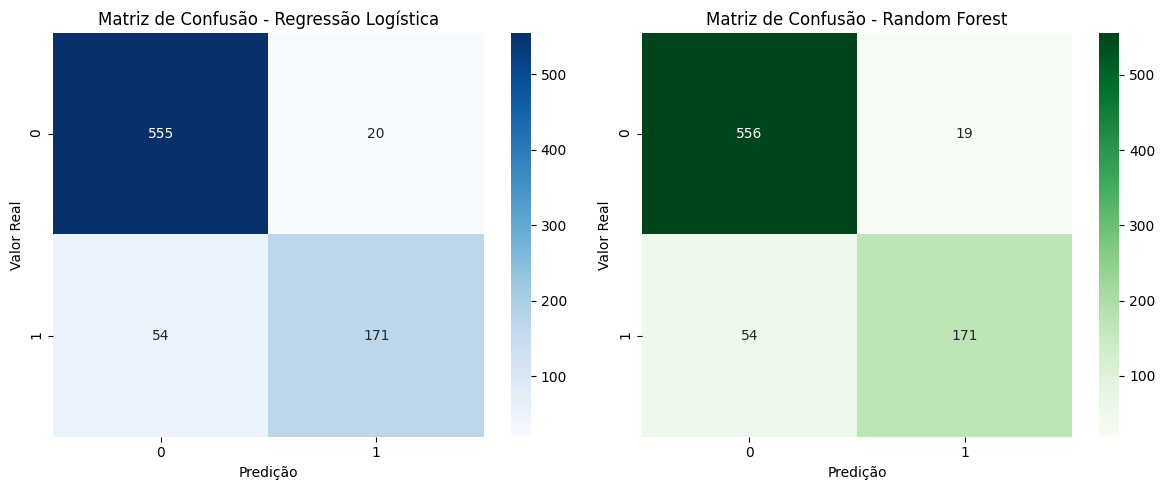

In [47]:
# Matriz de confusão para Regressão Logística
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
cm_lr = confusion_matrix(y_test, lr_predictions)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusão - Regressão Logística')
plt.ylabel('Valor Real')
plt.xlabel('Predição')

# Matriz de confusão para Random Forest
plt.subplot(1, 2, 2)
cm_rf = confusion_matrix(y_test, rf_predictions)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens')
plt.title('Matriz de Confusão - Random Forest')
plt.ylabel('Valor Real')
plt.xlabel('Predição')

plt.tight_layout()
plt.show()

Observações:
* Precisão: Dos clientes que o modelo previu que sairiam, quantos realmente saíram?
* Sensibilidade (Recall): Dos clientes que realmente saíram, quantos o modelo conseguiu identificar?

- Regressão Logistica

  TN(acertou quem fica) = 555

  FP(errou, achou que sairia, mas não saiu) = 20

  FN(errou, não previu churn) = 54

  TP(acertou churn) = 171

- Randon Forest

  TN(acertou quem fica) = 556

  FP(errou, achou que sairia, mas não saiu) = 19

  FN(errou, não previu churn) = 54

  TP(acertou churn) = 171

* Os modelos são muito parecidos, porém, Regressão Logistica é ligeiramente melhor. Mas deve-se melhorar a detecção de churn.

# 4 - Agrupamento de clientes

In [61]:
# Separar as características (excluir a coluna 'churn')
features_for_clustering = df.drop(columns=['churn'])

# Criar o objeto padronizador
scaler = StandardScaler()

# Padronizar os dados
features_scaled = scaler.fit_transform(features_for_clustering)

# Converter de volta para DataFrame
features_scaled_df = pd.DataFrame(features_scaled, columns=features_for_clustering.columns)

In [49]:
features_scaled_df.head()

,gender,near_location,partner,promo_friends,phone,contract_period,group_visits,age,avg_additional_charges_total,month_to_end_contract,lifetime,avg_class_frequency_total,avg_class_frequency_current_month
0,0.979706,0.427881,1.026861,1.497161,-3.059852,0.289890,1.194032,-0.056554,-1.377531,0.161605,-0.193329,-1.911920,-1.678472
1,-1.020715,0.427881,-0.973842,-0.667931,0.326813,1.608822,1.194032,0.557327,-0.350213,1.831941,0.873680,0.045176,0.136014
2,-1.020715,0.427881,1.026861,-0.667931,0.326813,-0.809219,-0.837498,-0.363494,-0.181592,-0.792873,-0.460081,-0.020493,-0.029019
3,-1.020715,0.427881,1.026861,1.497161,0.326813,1.608822,1.194032,1.171208,-0.874722,1.831941,-0.460081,1.364655,1.510450
4,0.979706,0.427881,1.026861,1.497161,0.326813,-0.809219,-0.837498,-0.977375,0.533700,-0.792873,-0.193329,-0.787076,-0.614542


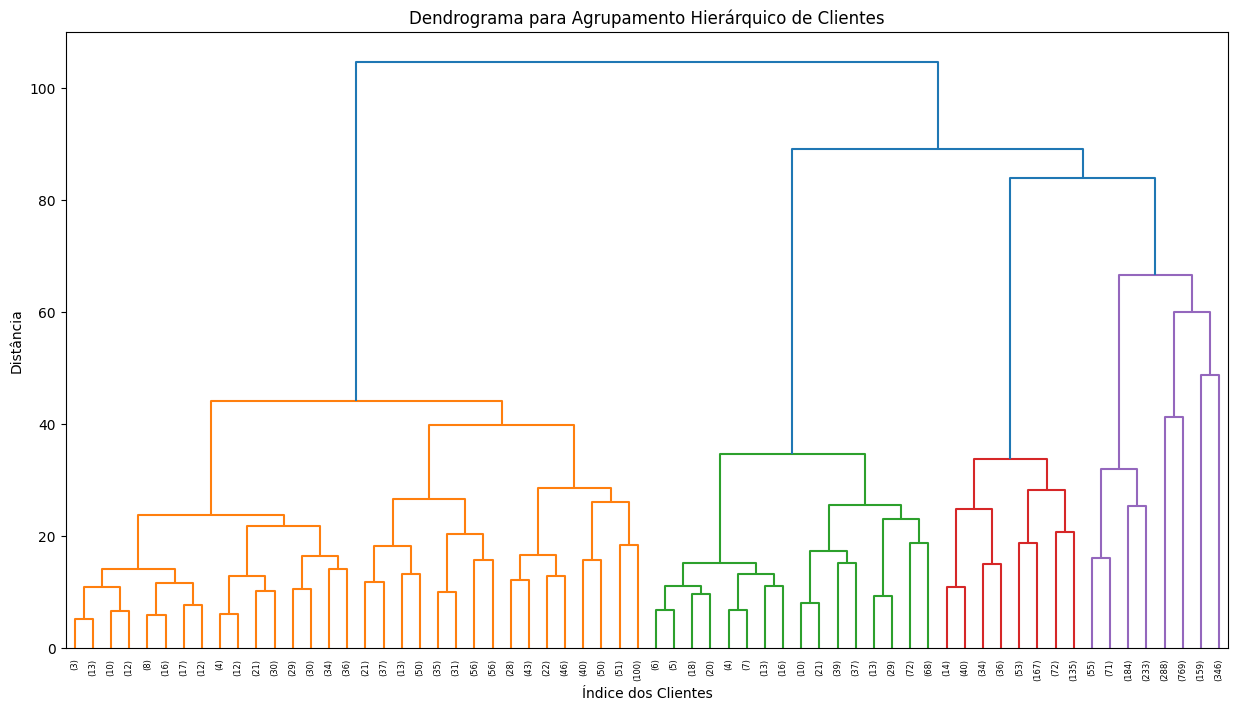

In [50]:
# Construir a matriz de distâncias usando linkage
# O método 'ward' minimiza a variância dentro dos clusters
linkage_matrix = linkage(features_scaled, method='ward')

# Criar o dendrograma
plt.figure(figsize=(15, 8))
dendrogram(linkage_matrix, truncate_mode='level', p=5)
plt.title('Dendrograma para Agrupamento Hierárquico de Clientes')
plt.xlabel('Índice dos Clientes')
plt.ylabel('Distância')
plt.show()

In [51]:
# definir o modelo k-means com 5 agrupamentos
km = KMeans(n_clusters=5, random_state=0)

In [52]:
# treinar e prever os agrupamentos para observações
labels = km.fit_predict(features_scaled)

In [53]:
# armazenar rótulos de agrupamento no campo do conjunto de dados
df['cluster_km'] = labels
features_scaled_df['cluster_km'] = labels

In [54]:
# obter as estatísticas dos valores médios de características por agrupamento
features_scaled_df.groupby(['cluster_km']).mean()

,gender,near_location,partner,promo_friends,phone,contract_period,group_visits,age,avg_additional_charges_total,month_to_end_contract,lifetime,avg_class_frequency_total,avg_class_frequency_current_month
cluster_km,,,,,,,,,,,,,
0,-0.014562,0.315639,0.593045,0.575389,0.326813,1.364623,0.264758,0.244917,0.143417,1.343834,0.269922,0.105990,0.197324
1,0.023661,0.047247,-0.033252,-0.004344,-3.059852,0.023249,0.027881,0.035927,-0.030994,0.036407,0.053331,-0.032712,-0.048142
2,-0.030407,-2.337100,-0.046784,-0.496438,0.326813,-0.511916,-0.399010,-0.217014,-0.119222,-0.507002,-0.244038,-0.224827,-0.275205
3,-0.049036,0.427881,-0.273120,-0.148103,0.326813,-0.600720,-0.143687,-0.311932,-0.159030,-0.588477,-0.342558,-0.649492,-0.716268
4,0.098853,0.361891,-0.259987,-0.169288,0.322772,-0.442237,0.124933,0.288846,0.152726,-0.444625,0.313118,1.000883,1.028815


In [55]:
# Ver quantos clientes há em cada cluster
print("Distribuição de clientes por cluster:")
print(df['cluster_km'].value_counts().sort_index())

# Ver as características médias de cada cluster (dados padronizados)
print("\nCaracterísticas médias por cluster (dados padronizados):")
cluster_means = features_scaled_df.groupby('cluster_km').mean()
print(cluster_means)

Distribuição de clientes por cluster:
0    1010
1     385
2     505
3    1262
4     838
Name: cluster_km, dtype: int64

Características médias por cluster (dados padronizados):
              gender  near_location   partner  promo_friends     phone  \
cluster_km                                                               
0          -0.014562       0.315639  0.593045       0.575389  0.326813   
1           0.023661       0.047247 -0.033252      -0.004344 -3.059852   
2          -0.030407      -2.337100 -0.046784      -0.496438  0.326813   
3          -0.049036       0.427881 -0.273120      -0.148103  0.326813   
4           0.098853       0.361891 -0.259987      -0.169288  0.322772   

            contract_period  group_visits       age  \
cluster_km                                            
0                  1.364623      0.264758  0.244917   
1                  0.023249      0.027881  0.035927   
2                 -0.511916     -0.399010 -0.217014   
3                 -0.600720  

In [56]:
def show_clusters_on_plot (df, x_name, y_name, cluster_name):
    plt.figure(figsize=(10,10))
    sns.scatterplot(df[x_name], df[y_name], hue=df[cluster_name], palette='Paired')
    plt.title('{} vs {}'.format(x_name, y_name))
    plt.show()

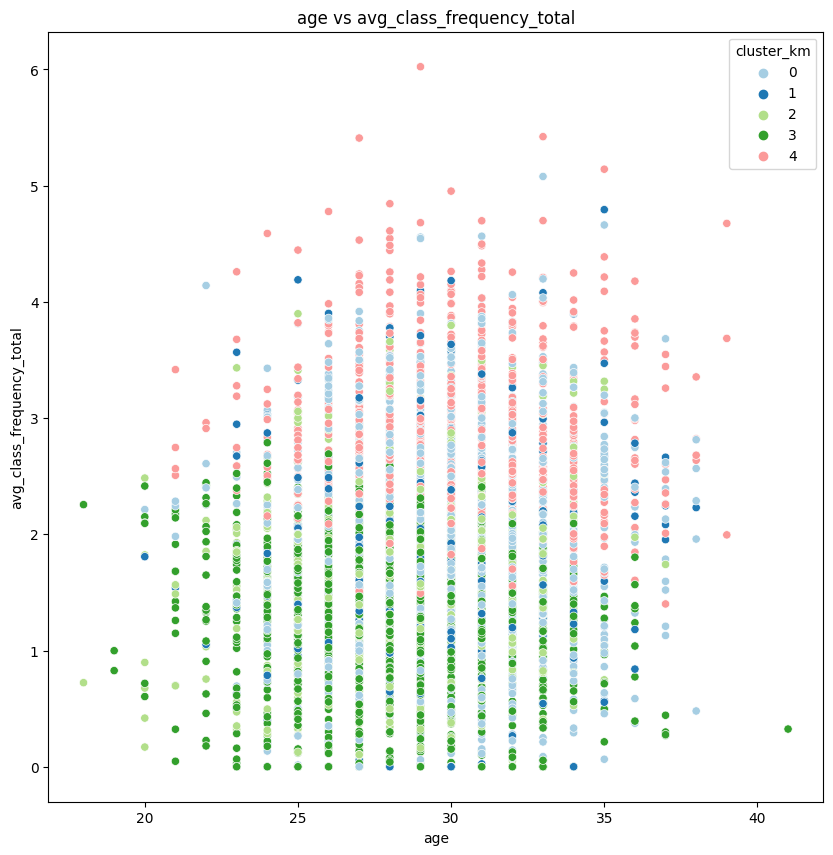

In [65]:
# gráfico para as caracteristicas age, avg_class_frequency_total
show_clusters_on_plot(df, 'age', 'avg_class_frequency_total','cluster_km')

In [67]:
# Calcular a taxa de rotatividade para cada cluster
churn_by_cluster = df.groupby('cluster_km')['churn'].agg(['count', 'sum', 'mean'])
churn_by_cluster.columns = ['total_clientes', 'clientes_churn', 'taxa_churn']
print("Taxa de rotatividade por cluster:")
print(churn_by_cluster)

Taxa de rotatividade por cluster:
            total_clientes  clientes_churn  taxa_churn
cluster_km                                            
0                     1010              28    0.027723
1                      385             103    0.267532
2                      505             224    0.443564
3                     1262             649    0.514263
4                      838              57    0.068019


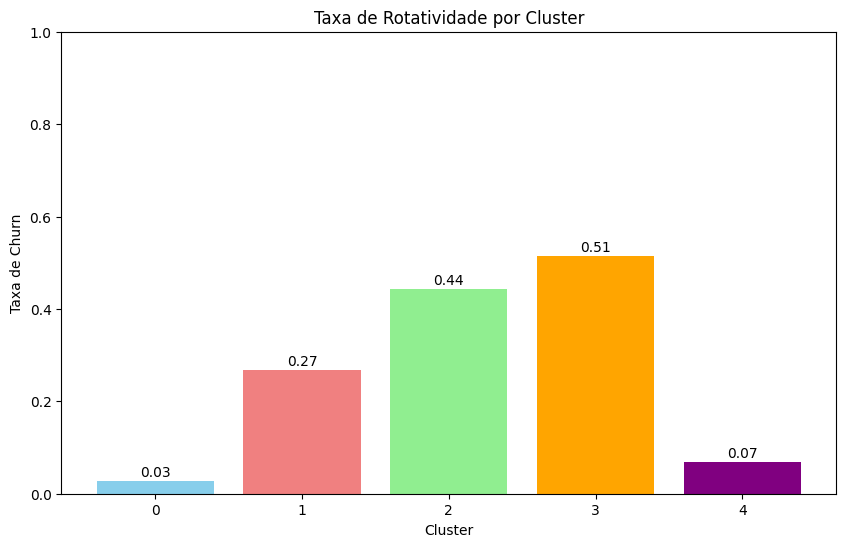

In [68]:
# Criar um gráfico de barras para visualizar as taxas de churn
plt.figure(figsize=(10, 6))
plt.bar(churn_by_cluster.index, churn_by_cluster['taxa_churn'], 
        color=['skyblue', 'lightcoral', 'lightgreen', 'orange', 'purple'])
plt.title('Taxa de Rotatividade por Cluster')
plt.xlabel('Cluster')
plt.ylabel('Taxa de Churn')
plt.ylim(0, 1)
# Adicionar valores nas barras
for i, v in enumerate(churn_by_cluster['taxa_churn']):
    plt.text(i, v + 0.01, f'{v:.2f}', ha='center')
plt.show()

# 5 - Recomendações

## 5.1 - 1º Recomendação
A variável avg_class_frequency_current_month (frequência no mês atual) é um dos indicadores mais críticos. Clientes que reduzem suas visitas para menos de 2 vezes por semana entram na zona de risco de churn.

Configurar alertas de automação no CRM. Se um aluno que costumava ir 3 vezes por semana não comparece há 7 dias, enviar uma notificação push ou SMS motivacional ou oferecer um convite para uma avaliação física gratuita para reengajá-lo.

## 5.2 - 2º Recomendação
Clientes com contratos de 1 mês têm uma probabilidade muito maior de sair do que aqueles com planos de 6 ou 12 meses.

No momento da renovação do plano mensal, oferecer um upgrade agressivo para o plano semestral ou anual (ex: "Pague 10 meses e ganhe 12").

## 5.3 - 3º Recomendação
A análise mostra que o risco de churn é mais alto nos primeiros meses de adesão. Uma vez que o cliente ultrapassa a marca de 5 meses de "Lifetime", a chance de ele sair diminui drasticamente.

Criar uma "Jornada de Integração de 90 dias". No primeiro mês, o foco é o acompanhamento técnico; no segundo, o foco é a socialização em grupos; no terceiro, oferecer um bônus por consistência. O objetivo é garantir que o aluno atinja o marco de 5 meses de permanência.